In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
plt.figure(figsize=(8, 8))

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

## Harris 角点检测

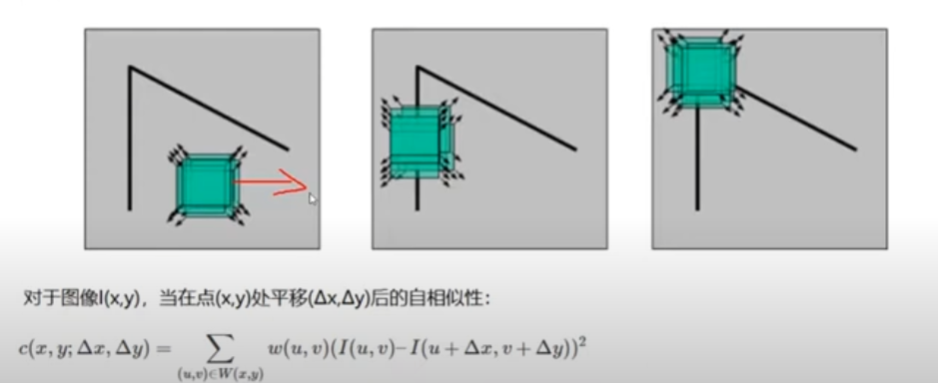

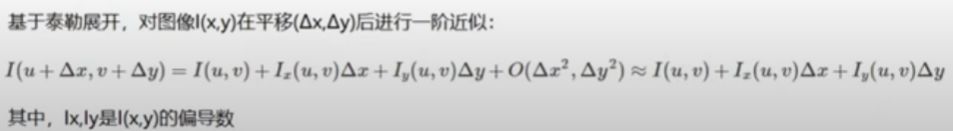

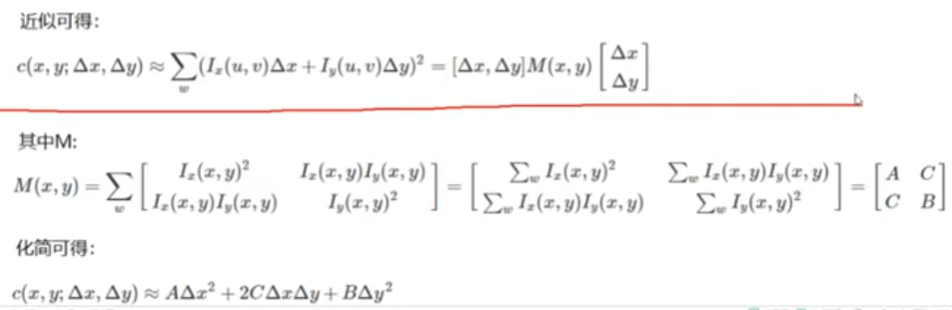

泰勒展开是一种将复杂的数学函数转化为多项式的方法。它的核心思想是用多项式来逼近一个函数，特别是在某个点附近。可以将一个函数看成是它在某点的值加上一系列项，每一项都是该点的导数信息的表现。

我们可以用简单的语言理解为：如果你想了解一个函数在某一点附近的行为（比如你想知道一个函数图像在某一点附近的形状），你可以通过泰勒展开来“猜测”这个函数的样子，猜测的准确度取决于你使用多少项。

### 直观理解

假设你有一个复杂的曲线（比如一个抛物线或更复杂的曲线），你想知道在某一点附近，这个曲线的形状。泰勒展开就像是告诉你：“我可以用一个多项式来近似这个曲线，而且这个多项式的形状在那一点附近和原函数非常接近。”

### 具体怎么做？

设想你有一个函数 $f(x)$，你想在 $x = a$ 这一点附近展开它。泰勒展开的基本公式是：

$$
f(x) = f(a) + f'(a)(x - a) + \frac{f''(a)}{2!}(x - a)^2 + \frac{f^{(3)}(a)}{3!}(x - a)^3 + \cdots
$$

这个式子其实是通过原函数的值和它在 $x = a$ 处的导数（即斜率、弯曲度等）来逐渐逼近函数的行为。

### 每一项的意义

* $f(a)$ 表示函数在 $x = a$ 处的值，即你已经知道的函数值。
* $f'(a)$ 是函数在 $x = a$ 处的导数，表示该点的切线斜率。
* $f''(a)$ 是函数在 $x = a$ 处的二阶导数，表示该点的曲率。
* $f^{(3)}(a)$ 是三阶导数，表示函数变化的“加速”程度，依此类推。

### 举个例子

假设你有一个简单的函数 $f(x) = e^x$，你想在 $x = 0$ 附近展开它。

* $f(0) = e^0 = 1$
* $f'(0) = e^0 = 1$
* $f''(0) = e^0 = 1$
* 所以，泰勒展开的前几项就是：

$$
e^x = 1 + 1(x - 0) + \frac{1}{2!}(x - 0)^2 + \frac{1}{3!}(x - 0)^3 + \cdots
$$

这就是 $e^x$ 在 $x = 0$ 附近的泰勒展开式。

### 为什么要用泰勒展开？

通过泰勒展开，我们可以将复杂的函数用多项式来近似，这对于计算和分析非常有用，特别是在处理高阶微积分和近似计算时。例如，当我们在计算机中无法精确表示某些复杂函数时，我们可以用泰勒展开的多项式近似它，从而得到一个非常接近的结果。

总结起来，泰勒展开就是将复杂函数通过多项式在某点附近展开，逐渐通过多项式的高阶项逼近原函数的行为。


### 然后是对角矩阵化简..............反正不懂，躺平

dst.shape (1706, 1279)
count ======  3474


(<Axes: title={'center': 'image'}>,
 Text(0.5, 1.0, 'image'),
 (-0.5, 1278.5, 1705.5, -0.5))

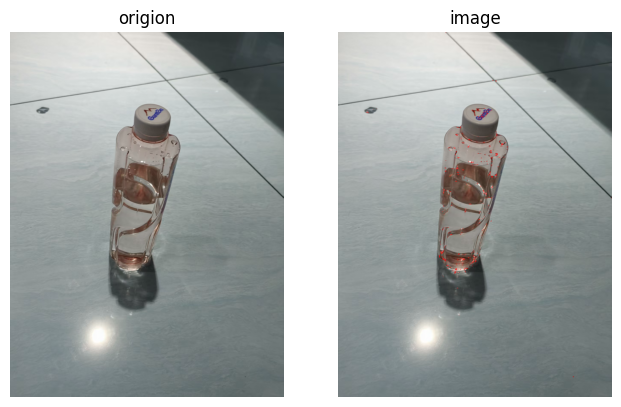

In [18]:
img = cv2.imread('./assets/1.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

dst = cv2.cornerHarris(gray, 2, 3, 0.04)
print('dst.shape', dst.shape)
image = img.copy()
threshold = 0.001 * dst.max()
count = np.sum(dst > threshold)
print('count ====== ', count)
image[dst>threshold] = [255, 0, 0]

plt.figure(figsize=(12, 12))
plt.subplot(231), plt.imshow(img), plt.title("origion"), plt.axis('off')
plt.subplot(232), plt.imshow(image), plt.title("image"), plt.axis('off')